# Exercise 1 — D-1 BESS Trading Strategy Analysis

**Date:** 16 March 2026  
**Region:** VIC

This notebook analyses D-1 market conditions for battery storage trading in VIC.  
The objective is to interpret market behaviour, identify likely charging and discharging opportunities, and develop a trader recommendation for 08:30 using available early information and prior observed market patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading merged data set 

In [2]:
merged_df = pd.read_csv("/Users/vivekarya/Documents/GitHub/bess_trading_assessment/data/processed/merged_dataset.csv")

merged_df["SETTLEMENTDATE"] = pd.to_datetime(merged_df["SETTLEMENTDATE"])
merged_df["DATE"] = pd.to_datetime(merged_df["DATE"])

print(merged_df.shape)
merged_df.head()

(338, 9)


,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE
0,VIC1,2026-03-09 00:00:00,61.873592,4681,0.0,4681.0,2026-03-09,0,0
1,VIC1,2026-03-09 00:30:00,60.998663,4490,0.0,4490.0,2026-03-09,0,30
2,VIC1,2026-03-09 01:00:00,65.790635,4392,0.0,4392.0,2026-03-09,1,0
3,VIC1,2026-03-09 01:30:00,67.643523,4302,0.0,4302.0,2026-03-09,1,30
4,VIC1,2026-03-09 02:00:00,63.400825,4211,0.0,4211.0,2026-03-09,2,0


## Creating the datasets needed for Exercise 1

In [3]:
# Historical week used to understand pattern
weekly_support_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-09") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-16")
].copy()

# 16 March data available in the merged file
d1_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-16") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-17")
].copy()

# What a trader would know by 08:30
d1_early_df = d1_df[
    d1_df["SETTLEMENTDATE"] <= "2026-03-16 08:30:00"
].copy()

print("Weekly support shape:", weekly_support_df.shape)
print("D-1 shape:", d1_df.shape)
print("D-1 early view shape:", d1_early_df.shape)

Weekly support shape: (329, 9)
D-1 shape: (9, 9)
D-1 early view shape: (9, 9)


## Data Scope for Exercise 1

This exercise focuses on **16 March 2026** in VIC.  
To support the D-1 interpretation:

- data from **9–15 March 2026** is used to understand recurring market patterns
- early-morning data from **16 March 2026** is used to simulate the information available to a trader before 08:30

This approach reflects how traders use recent market behaviour to guide decisions under incomplete information.

### Weekly support pattern by hour

In [4]:
hourly_support = weekly_support_df.groupby("HOUR")[["RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]].mean()
hourly_support

,RRP,TOTALDEMAND,PV_MW,NET_DEMAND
HOUR,,,,
0,30.633951,4762.500000,0.000000,4762.500000
1,28.167502,4499.714286,0.000000,4499.714286
2,26.191857,4322.000000,0.000000,4322.000000
3,28.406502,4261.000000,0.000000,4261.000000
4,33.692552,4325.071429,0.000000,4325.071429
5,37.255169,4578.857143,0.000000,4578.857143
6,39.346619,5051.214286,23.667571,5027.546714
7,7.562271,5206.642857,417.844786,4788.798071
8,-6.313550,4858.785714,1120.161143,3738.624571


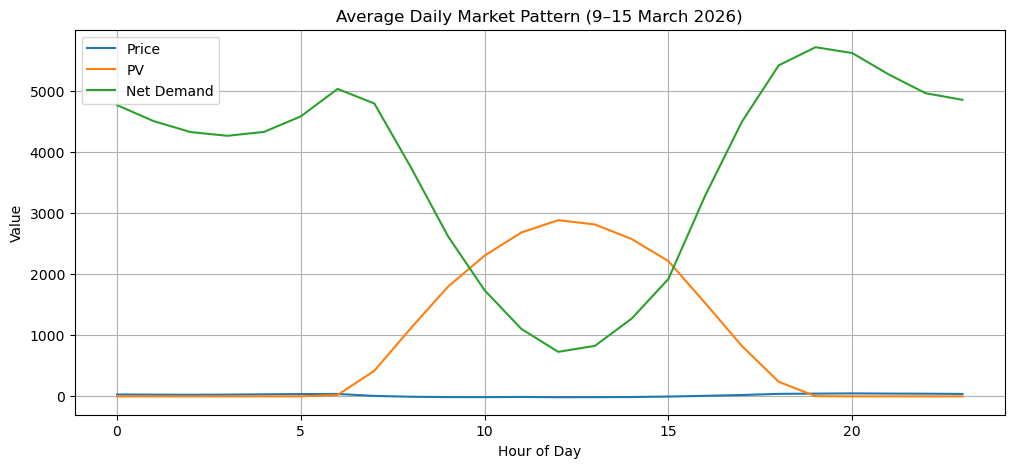

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_support.index, hourly_support["RRP"], label="Price")
plt.plot(hourly_support.index, hourly_support["PV_MW"], label="PV")
plt.plot(hourly_support.index, hourly_support["NET_DEMAND"], label="Net Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Value")
plt.title("Average Daily Market Pattern (9–15 March 2026)")
plt.legend()
plt.grid(True)
plt.show()

## Support Pattern Insight

The historical weekly pattern shows a clear solar-driven market structure:

- overnight prices are relatively stable with zero PV generation
- prices decline sharply during the morning as rooftop PV increases
- midday periods show the weakest and often negative prices
- evening periods show higher prices as solar generation falls and net demand rises

This pattern suggests that batteries are most likely to find charging opportunities during solar-driven low-price periods and discharging opportunities during evening peak demand periods.

## Check early-morning D-1 conditions

In [6]:
d1_early_df[["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]]

,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND
329,2026-03-16 00:00:00,68.530705,4764,0.0,4764.0
330,2026-03-16 00:30:00,63.653745,4617,0.0,4617.0
331,2026-03-16 01:00:00,60.242388,4542,0.0,4542.0
332,2026-03-16 01:30:00,57.015702,4500,0.0,4500.0
333,2026-03-16 02:00:00,60.327218,4400,0.0,4400.0
334,2026-03-16 02:30:00,58.578307,4317,0.0,4317.0
335,2026-03-16 03:00:00,57.634825,4316,0.0,4316.0
336,2026-03-16 03:30:00,60.076228,4306,0.0,4306.0
337,2026-03-16 04:00:00,65.490510,4337,0.0,4337.0


## Plot early-morning D-1 conditions

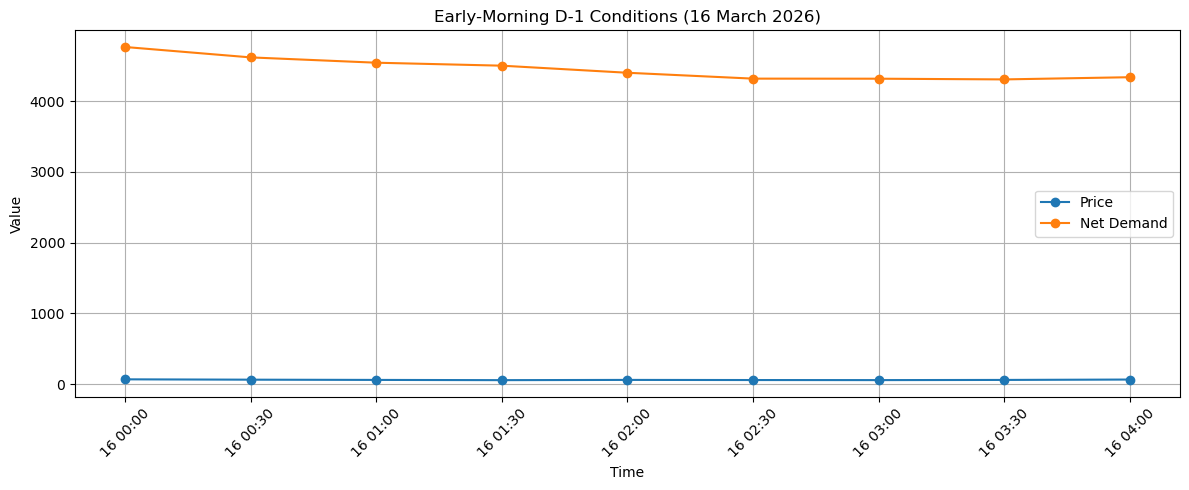

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(d1_early_df["SETTLEMENTDATE"], d1_early_df["RRP"], marker="o", label="Price")

plt.plot(d1_early_df["SETTLEMENTDATE"], d1_early_df["NET_DEMAND"], marker="o", label="Net Demand")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Early-Morning D-1 Conditions (16 March 2026)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Early-Morning D-1 Interpretation

The early-morning market on 16 March shows relatively stable conditions, with rooftop PV still negligible and demand moderate.  
This indicates that strong charging opportunities are unlikely to emerge in the early hours.  
Based on the historical pattern, stronger solar-driven price weakness would be expected later in the morning and around midday.

###  Finding  strongest charging and discharging candidates from available D-1 data

In [8]:
d1_df = d1_df.copy()

low_threshold = d1_df["RRP"].quantile(0.25)
high_threshold = d1_df["RRP"].quantile(0.75)

def signal(price):
    if price <= low_threshold:
        return "CHARGE"
    elif price >= high_threshold:
        return "DISCHARGE"
    else:
        return "HOLD"

d1_df["TRADING_SIGNAL"] = d1_df["RRP"].apply(signal)

d1_df[["SETTLEMENTDATE", "RRP", "TRADING_SIGNAL"]]

,SETTLEMENTDATE,RRP,TRADING_SIGNAL
329,2026-03-16 00:00:00,68.530705,DISCHARGE
330,2026-03-16 00:30:00,63.653745,DISCHARGE
331,2026-03-16 01:00:00,60.242388,HOLD
332,2026-03-16 01:30:00,57.015702,CHARGE
333,2026-03-16 02:00:00,60.327218,HOLD
334,2026-03-16 02:30:00,58.578307,CHARGE
335,2026-03-16 03:00:00,57.634825,CHARGE
336,2026-03-16 03:30:00,60.076228,HOLD
337,2026-03-16 04:00:00,65.490510,DISCHARGE


In [9]:
print("Lowest available D-1 prices:")
print(
    d1_df.sort_values("RRP")[
        ["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND", "TRADING_SIGNAL"]
    ].head(10)
)

print("\nHighest available D-1 prices:")
print(
    d1_df.sort_values("RRP", ascending=False)[
        ["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND", "TRADING_SIGNAL"]
    ].head(10)
)

Lowest available D-1 prices:
         SETTLEMENTDATE        RRP  TOTALDEMAND  PV_MW  NET_DEMAND  \
332 2026-03-16 01:30:00  57.015702         4500    0.0      4500.0   
335 2026-03-16 03:00:00  57.634825         4316    0.0      4316.0   
334 2026-03-16 02:30:00  58.578307         4317    0.0      4317.0   
336 2026-03-16 03:30:00  60.076228         4306    0.0      4306.0   
331 2026-03-16 01:00:00  60.242388         4542    0.0      4542.0   
333 2026-03-16 02:00:00  60.327218         4400    0.0      4400.0   
330 2026-03-16 00:30:00  63.653745         4617    0.0      4617.0   
337 2026-03-16 04:00:00  65.490510         4337    0.0      4337.0   
329 2026-03-16 00:00:00  68.530705         4764    0.0      4764.0   

    TRADING_SIGNAL  
332         CHARGE  
335         CHARGE  
334         CHARGE  
336           HOLD  
331           HOLD  
333           HOLD  
330      DISCHARGE  
337      DISCHARGE  
329      DISCHARGE  

Highest available D-1 prices:
         SETTLEMENTDATE      

## Implementing BESS SOC

In [11]:
bess_df = d1_df.copy().sort_values("SETTLEMENTDATE").reset_index(drop=True)

print(bess_df.shape)
bess_df.head()

(9, 10)


,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE,TRADING_SIGNAL
0,VIC1,2026-03-16 00:00:00,68.530705,4764,0.0,4764.0,2026-03-16,0,0,DISCHARGE
1,VIC1,2026-03-16 00:30:00,63.653745,4617,0.0,4617.0,2026-03-16,0,30,DISCHARGE
2,VIC1,2026-03-16 01:00:00,60.242388,4542,0.0,4542.0,2026-03-16,1,0,HOLD
3,VIC1,2026-03-16 01:30:00,57.015702,4500,0.0,4500.0,2026-03-16,1,30,CHARGE
4,VIC1,2026-03-16 02:00:00,60.327218,4400,0.0,4400.0,2026-03-16,2,0,HOLD


## Defining battery assumptions

In [12]:
# Battery assumptions
BATTERY_CAPACITY_MWH = 400
ROUND_TRIP_EFFICIENCY = 0.93

# Assume a simple 2-hour battery
BATTERY_POWER_MW = 200

# 30-minute interval length
INTERVAL_HOURS = 0.5

# Initial SOC
initial_soc_mwh = 0.0

## Create thresholds for  trading

In [13]:
low_price_threshold = bess_df["RRP"].quantile(0.25)
high_price_threshold = bess_df["RRP"].quantile(0.75)

print("Low price threshold:", low_price_threshold)
print("High price threshold:", high_price_threshold)

Low price threshold: 58.57830666666666
High price threshold: 63.653744999999994


## Adding empty BESS columns

In [14]:
bess_df["ACTION"] = "HOLD"
bess_df["SOC_MWH"] = 0.0
bess_df["CHARGE_MWH"] = 0.0
bess_df["DISCHARGE_MWH"] = 0.0

## Running the SOC simulation

In [15]:
soc = initial_soc_mwh

for i in range(len(bess_df)):
    price = bess_df.loc[i, "RRP"]

    # max energy moved in one 30-minute interval
    interval_energy_mwh = BATTERY_POWER_MW * INTERVAL_HOURS  # 100 MWh

    # charge when price is relatively low
    if price <= low_price_threshold:
        available_space = BATTERY_CAPACITY_MWH - soc
        charge_mwh = min(interval_energy_mwh, available_space)

        # simplified efficiency treatment
        soc += charge_mwh * ROUND_TRIP_EFFICIENCY

        bess_df.loc[i, "ACTION"] = "CHARGE"
        bess_df.loc[i, "CHARGE_MWH"] = charge_mwh

    # discharge when price is relatively high
    elif price >= high_price_threshold:
        discharge_mwh = min(interval_energy_mwh, soc)

        soc -= discharge_mwh

        bess_df.loc[i, "ACTION"] = "DISCHARGE"
        bess_df.loc[i, "DISCHARGE_MWH"] = discharge_mwh

    else:
        bess_df.loc[i, "ACTION"] = "HOLD"

    bess_df.loc[i, "SOC_MWH"] = soc

In [16]:
bess_df[["SETTLEMENTDATE", "RRP", "ACTION", "CHARGE_MWH", "DISCHARGE_MWH", "SOC_MWH"]]


,SETTLEMENTDATE,RRP,ACTION,CHARGE_MWH,DISCHARGE_MWH,SOC_MWH
0,2026-03-16 00:00:00,68.530705,DISCHARGE,0.0,0.0,0.0
1,2026-03-16 00:30:00,63.653745,DISCHARGE,0.0,0.0,0.0
2,2026-03-16 01:00:00,60.242388,HOLD,0.0,0.0,0.0
3,2026-03-16 01:30:00,57.015702,CHARGE,100.0,0.0,93.0
4,2026-03-16 02:00:00,60.327218,HOLD,0.0,0.0,93.0
5,2026-03-16 02:30:00,58.578307,CHARGE,100.0,0.0,186.0
6,2026-03-16 03:00:00,57.634825,CHARGE,100.0,0.0,279.0
7,2026-03-16 03:30:00,60.076228,HOLD,0.0,0.0,279.0
8,2026-03-16 04:00:00,65.490510,DISCHARGE,0.0,100.0,179.0


## SOC Simulation Behaviour — Early Morning

The SOC simulation shows that the battery initiates charging during relatively lower-price intervals within the early-morning window. However, these prices (approximately $57–$60/MWh) are only low relative to the limited early-morning range and do not represent genuinely attractive charging conditions in an absolute market context.

From a practical trading perspective, these price levels are not sufficiently low to justify battery charging, particularly given the expectation of significantly lower or negative prices later in the day driven by solar generation.

This highlights a limitation of using relative price thresholds over a narrow time window. While the model identifies “lower” prices within the early dataset, these do not correspond to true arbitrage opportunities.

As a result, the SOC behaviour should be interpreted cautiously. A real trader would likely avoid charging during this period and instead wait for stronger solar-driven price suppression before committing to charging.

In [17]:
print(bess_df["ACTION"].value_counts())
print("Max SOC:", bess_df["SOC_MWH"].max())
print("Min SOC:", bess_df["SOC_MWH"].min())

ACTION
DISCHARGE    3
HOLD         3
CHARGE       3
Name: count, dtype: int64
Max SOC: 279.0
Min SOC: 0.0


## SOC Simulation Summary

The SOC simulation shows an even distribution of actions, with 3 charge, 3 discharge, and 3 hold intervals. This balanced distribution indicates that the battery is responding to relatively small variations in price rather than strong arbitrage signals.

At the beginning of the period, the battery attempts to discharge during higher-price intervals. However, since the initial state of charge is 0 MWh, no actual discharge occurs. This highlights a key operational constraint — the battery must first accumulate energy before participating in high-price periods.

As the simulation progresses, the battery gradually charges, reaching a maximum SOC of approximately 279 MWh. However, this charging occurs at relatively moderate price levels rather than truly low or negative prices, indicating suboptimal charging conditions.

Overall, the simulation does not capture a strong arbitrage cycle, as the early-morning price range is narrow and lacks significant price differentials. This suggests that early-morning market conditions are not conducive to effective battery trading and that stronger opportunities are likely to emerge later in the day.

## SOC plot

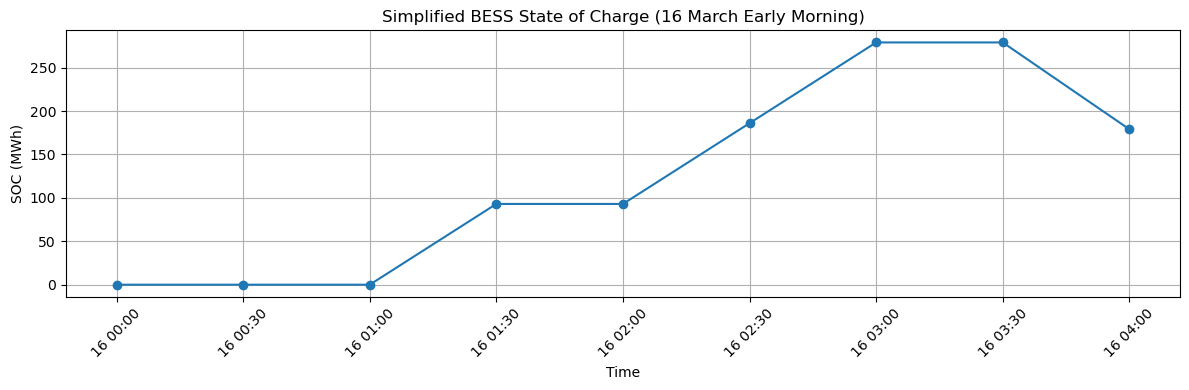

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(bess_df["SETTLEMENTDATE"], bess_df["SOC_MWH"], marker="o")
plt.xlabel("Time")
plt.ylabel("SOC (MWh)")
plt.title("Simplified BESS State of Charge (16 March Early Morning)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Early-Morning Price Behaviour (D-1)

The early-morning data for 16 March (00:00–04:00) shows relatively stable price conditions, with prices ranging between approximately $57/MWh and $68/MWh. During this period, rooftop PV generation is zero, and demand remains moderate, resulting in normal overnight market conditions without strong supply-demand imbalance.

The trading signals generated from this period classify higher-price intervals as potential discharge points and lower-price intervals as potential charging points. However, these signals are relative to the limited early-morning price range and do not represent strong arbitrage opportunities.

Importantly, no negative prices or significant price volatility are observed during this period. This indicates that early-morning conditions do not provide strong incentives for immediate battery charging or discharging.

Based on historical weekly patterns, stronger charging opportunities are expected later in the day as solar generation increases and net demand decreases. Therefore, early-morning signals should be interpreted with caution and not acted upon immediately.

## Trader Recommendation at 08:30

At 08:30, the recommended strategy is to **avoid immediate charging or discharging and preserve state of charge for later opportunities**.

The available early-morning data (00:00–04:00) shows relatively stable prices in the range of $57–$68/MWh, with no solar generation and no indication of oversupply conditions. The trading signals derived from this period are based on a narrow price range and do not represent strong arbitrage opportunities.

Historical patterns from the previous week indicate that rooftop PV generation typically increases significantly during the morning, leading to a reduction in net demand and a higher likelihood of lower or negative prices during late morning and midday periods.

Based on this, it is expected that more attractive charging opportunities will emerge later in the day as solar generation increases. Therefore, charging should be delayed until clearer solar-driven price weakness is observed.

The preferred discharge window would then be in the late afternoon or evening period, when solar generation declines and net demand increases, leading to stronger price conditions.

### Strategy Summary
- **Immediate action:** HOLD (no charging or discharging at 08:30)
- **Expected charging window:** Late morning to midday
- **Expected discharging window:** Evening peak period
- **Approach:** Preserve optionality and avoid committing early under uncertain conditions

### Key Risks and Considerations

- Uncertainty in rooftop PV generation due to weather conditions  
- Demand variability relative to expected patterns  
- Forecast error in price expectations  
- Potential impact of network constraints, outages, or interconnector flows  
- Possibility that FCAS markets may offer better value than energy arbitrage

## BESS-Focused Assessment

### Optimal Charge/Discharge Strategy
The optimal strategy would have been to avoid immediate early-morning charging and preserve flexibility for stronger opportunities later in the day. Based on the recurring pattern observed across the previous week, rooftop PV generation was expected to increase through the morning, reducing net demand and creating lower or negative midday prices. The preferred strategy would therefore be to charge during late morning to midday solar-driven weakness and discharge during the late afternoon or evening peak when solar generation declines and net demand increases.

### Most Attractive Trading Windows
- **Charging window:** Late morning to midday, when strong rooftop PV output is expected to suppress prices
- **Discharging window:** Late afternoon to evening, when declining solar output and rising net demand support stronger prices

### Strategy Suitability
- **Full cycling:** Not clearly supported by early-morning signals alone; only attractive if later spreads widened materially
- **Partial cycling:** More suitable under moderate spread conditions
- **FCAS participation:** Potentially attractive if energy spreads remained weak
- **Holding SOC for optionality:** Appropriate at 08:30, given the lack of strong early charging conditions and the expectation of better later opportunities

### Key Risks and Uncertainties
- uncertainty in rooftop PV generation due to weather variability
- deviations in demand from expected patterns
- forecast error in predispatch price expectations
- potential market impacts from outages, network constraints, or interconnector limitations
- the possibility that FCAS markets could offer better value than energy arbitrage in a weak-spread environment